In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
class GMM:
    def __init__(self, n_components=2, max_iter=100, tol=1e-4):
        self.k = n_components
        self.max_iter = max_iter
        self.tol = tol

    def _gaussian(self, X, mean, cov):
        n = X.shape[1]
        diff = X - mean
        inv = np.linalg.inv(cov)
        det = np.linalg.det(cov)

        exponent = np.einsum('ij,jk,ik->i', diff, inv, diff)
        return (1.0 / np.sqrt((2 * np.pi) ** n * det)) * np.exp(-0.5 * exponent)

    def fit(self, X):
        n_samples, n_features = X.shape

        np.random.seed(42)
        self.means = X[np.random.choice(n_samples, self.k, replace=False)]
        self.covs = np.array([np.eye(n_features) for _ in range(self.k)])
        self.weights = np.ones(self.k) / self.k

        log_likelihood_old = 0

        for _ in range(self.max_iter):

            # E-step
            resp = np.zeros((n_samples, self.k))
            for j in range(self.k):
                resp[:, j] = self.weights[j] * self._gaussian(X, self.means[j], self.covs[j])

            resp_sum = np.sum(resp, axis=1, keepdims=True)
            resp = resp / resp_sum

            # M-step
            Nk = np.sum(resp, axis=0)

            self.weights = Nk / n_samples
            self.means = np.dot(resp.T, X) / Nk[:, np.newaxis]

            self.covs = np.zeros((self.k, n_features, n_features))
            for j in range(self.k):
                diff = X - self.means[j]
                self.covs[j] = np.dot(resp[:, j] * diff.T, diff) / Nk[j]

            # Check convergence
            log_likelihood = np.sum(np.log(resp_sum))
            if abs(log_likelihood - log_likelihood_old) < self.tol:
                break
            log_likelihood_old = log_likelihood

        print("✅ GMM training completed!")

    def sample(self, n_samples=100):
        samples = []
        component_choices = np.random.choice(self.k, size=n_samples, p=self.weights)
        for comp in component_choices:
            sample = np.random.multivariate_normal(self.means[comp], self.covs[comp])
            samples.append(sample)
        return np.array(samples)


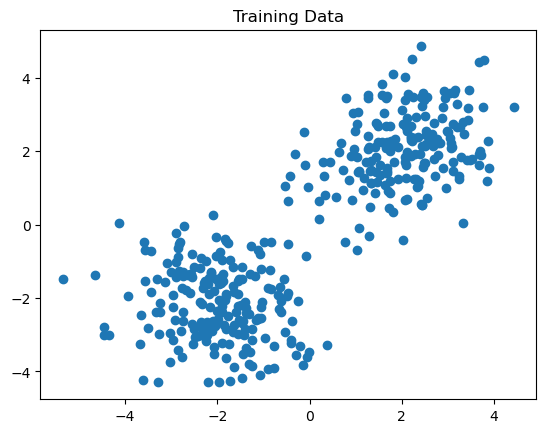

In [3]:
np.random.seed(0)

X1 = np.random.multivariate_normal([2, 2], [[1, 0.3], [0.3, 1]], 200)
X2 = np.random.multivariate_normal([-2, -2], [[1, -0.2], [-0.2, 1]], 200)

X = np.vstack([X1, X2])

plt.scatter(X[:, 0], X[:, 1])
plt.title("Training Data")
plt.show()


In [4]:
gmm = GMM(n_components=2)
gmm.fit(X)


✅ GMM training completed!


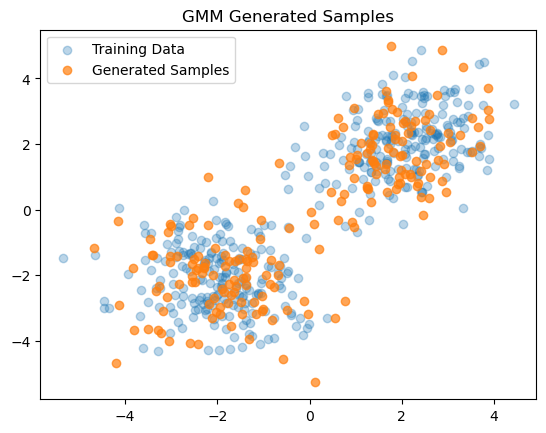

In [5]:
new_samples = gmm.sample(200)

plt.scatter(X[:, 0], X[:, 1], alpha=0.3, label="Training Data")
plt.scatter(new_samples[:, 0], new_samples[:, 1], alpha=0.7, label="Generated Samples")
plt.legend()
plt.title("GMM Generated Samples")
plt.show()
